Classes detetadas: ['Anthropic' 'Google' 'Human' 'Meta' 'OpenAI']
A usar dispositivo: cuda


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8946.37it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



======== Época 1 / 4 ========
Loss média de Treino: 0.5891
Accuracy de Validação: 0.9256

======== Época 2 / 4 ========
Loss média de Treino: 0.1591
Accuracy de Validação: 0.9601

======== Época 3 / 4 ========
Loss média de Treino: 0.0811
Accuracy de Validação: 0.8986

======== Época 4 / 4 ========
Loss média de Treino: 0.0297
Accuracy de Validação: 0.9407

Relatório de Classificação Final:
              precision    recall  f1-score   support

   Anthropic       0.99      0.97      0.98       181
      Google       0.95      0.83      0.89       181
       Human       0.99      0.97      0.98       204
        Meta       0.81      0.99      0.90       181
      OpenAI       0.98      0.93      0.96       180

    accuracy                           0.94       927
   macro avg       0.95      0.94      0.94       927
weighted avg       0.95      0.94      0.94       927



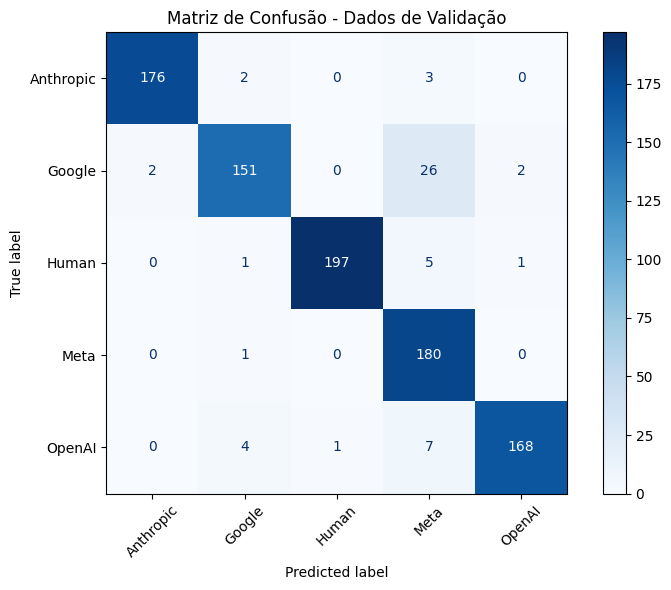

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]


('./meu_modelo_ai_detector\\tokenizer_config.json',
 './meu_modelo_ai_detector\\tokenizer.json')

In [9]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import random

# Definir a semente para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ==========================================
# 1. PRÉ-PROCESSAMENTO E CARREGAMENTO
# ==========================================

# Carregar o dataset (ajustado para o separador ';' do teu ficheiro)
df = pd.read_csv('dataset_final.csv', sep=';')

# Limpar possíveis valores nulos
df = df.dropna(subset=['Text', 'Label'])

# Codificar as Labels (Human, OpenAI, Google, Anthropic, Meta) para inteiros (0 a 4)
label_encoder = LabelEncoder()
df['Encoded_Label'] = label_encoder.fit_transform(df['Label'])
num_labels = len(label_encoder.classes_)
print(f"Classes detetadas: {label_encoder.classes_}")

# Dividir em Treino e Validação (80% treino, 20% validação)
# O stratify garante que a proporção de classes se mantém equilibrada em ambos os sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Text'].tolist(), 
    df['Encoded_Label'].tolist(), 
    test_size=0.2, 
    random_state=42, 
    stratify=df['Encoded_Label'].tolist()
)

# ==========================================
# 2. CONFIGURAÇÃO DO TRANSFORMER
# ==========================================
MODEL_NAME = "roberta-base" # RoBERTa costuma ser excelente para distinção de texto AI vs Humano
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # ALTERAÇÃO AQUI: Chamar o tokenizer diretamente em vez de usar encode_plus
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Criar Datasets e DataLoaders
train_dataset = TextClassificationDataset(train_texts, train_labels, tokenizer)
val_dataset = TextClassificationDataset(val_texts, val_labels, tokenizer)

BATCH_SIZE = 16
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ==========================================
# 3. INICIALIZAR O MODELO DE DEEP LEARNING
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar dispositivo: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=num_labels
)
model = model.to(device)

# Hiperparâmetros recomendados para Fine-Tuning
EPOCHS = 4
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# ==========================================
# 4. CICLO DE TREINO E VALIDAÇÃO (PYTORCH)
# ==========================================
for epoch in range(EPOCHS):
    print(f"\n======== Época {epoch + 1} / {EPOCHS} ========")
    
    # TREINO
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        model.zero_grad()

        outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Previne exploding gradients
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Loss média de Treino: {avg_train_loss:.4f}")

    # VALIDAÇÃO
    model.eval()
    val_preds, val_true = [], []

    for batch in val_dataloader:
        b_input_ids = batch['input_ids'].to(device)
        b_input_mask = batch['attention_mask'].to(device)
        b_labels = batch['labels'].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, attention_mask=b_input_mask)

        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        val_preds.extend(np.argmax(logits, axis=1).flatten())
        val_true.extend(label_ids.flatten())

    val_accuracy = accuracy_score(val_true, val_preds)
    print(f"Accuracy de Validação: {val_accuracy:.4f}")

# ==========================================
# 5. RESULTADOS FINAIS
# ==========================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\nRelatório de Classificação Final:")
print(classification_report(val_true, val_preds, target_names=label_encoder.classes_))

# --- CÓDIGO NOVO: GERAR A MATRIZ DE CONFUSÃO ---
# Calcular a matriz usando os valores reais (val_true) e as predições (val_preds)
cm = confusion_matrix(val_true, val_preds)

# Configurar o tamanho e o estilo do gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# Desenhar a matriz
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Matriz de Confusão - Dados de Validação')
plt.tight_layout()
plt.show()
# -----------------------------------------------

# (Opcional) Guardar o modelo para entregar / usar nos testes do professor
model.save_pretrained('./meu_modelo_ai_detector')
tokenizer.save_pretrained('./meu_modelo_ai_detector')

In [10]:
import pandas as pd
import torch
import numpy as np
from torch.utils.data import DataLoader

# ==========================================
# GERAÇÃO DE PREDIÇÕES PARA A SUBMISSÃO 3
# ==========================================

# 1. Carregar o ficheiro da 3ª submissão
# Confirma se o nome do ficheiro e a coluna estão corretos ('Text' ou 'texto')
df_subm3 = pd.read_csv('subm3.csv', sep=';')
df_subm3 = df_subm3.dropna(subset=['Text'])

# 2. Criar DataLoader com "Dummy Labels"
# Como não temos a coluna 'Label', dizemos ao modelo que são todos '0' só para o código correr
dummy_labels_3 = [0] * len(df_subm3)
test_dataset_3 = TextClassificationDataset(df_subm3['Text'].tolist(), dummy_labels_3, tokenizer)
test_dataloader_3 = DataLoader(test_dataset_3, batch_size=16)

# 3. Fazer as Predições
model.eval()
test_preds_3 = []

print("A gerar predições finais para a Submissão 3...")
for batch in test_dataloader_3:
    b_input_ids = batch['input_ids'].to(device)
    b_input_mask = batch['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(b_input_ids, attention_mask=b_input_mask)
        
    logits = outputs.logits.detach().cpu().numpy()
    test_preds_3.extend(np.argmax(logits, axis=1).flatten())

# 4. Converter as predições numéricas de volta para texto e Guardar no CSV
df_subm3['Predicted_Label'] = label_encoder.inverse_transform(test_preds_3)
df_subm3.to_csv('predicoes_finais_subm3.csv', index=False, sep=';')

print("\n✅ Ficheiro 'predicoes_finais_subm3.csv' gerado com sucesso!")

# ==========================================
# 5. SANITY CHECK: VER A DISTRIBUIÇÃO DAS CLASSES
# ==========================================
print("\n======================================")
print("Distribuição das Predições (Submissão 3):")
print("======================================")

contagem = df_subm3['Predicted_Label'].value_counts()
percentagem = df_subm3['Predicted_Label'].value_counts(normalize=True) * 100

df_distribuicao = pd.DataFrame({
    'Contagem': contagem, 
    'Percentagem (%)': percentagem.round(2)
})

print(df_distribuicao)
print("======================================")

A gerar predições finais para a Submissão 3...

✅ Ficheiro 'predicoes_finais_subm3.csv' gerado com sucesso!

Distribuição das Predições (Submissão 3):
                 Contagem  Percentagem (%)
Predicted_Label                           
Meta                   56            37.33
Google                 45            30.00
Human                  38            25.33
OpenAI                  6             4.00
Anthropic               5             3.33
